<a href="https://colab.research.google.com/github/kavithagtamil-create/Model_Building_CV_GK/blob/main/CIFAR_10_DL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#https://www.youtube.com/watch?v=7HPwo4wnJeA
from tensorflow.keras import datasets,layers,models
import tensorflow as tf
import matplotlib.pyplot as plt


In [ ]:
(X_train,y_train), (X_test,y_test)=datasets.cifar10.load_data()


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2191s 13us/step


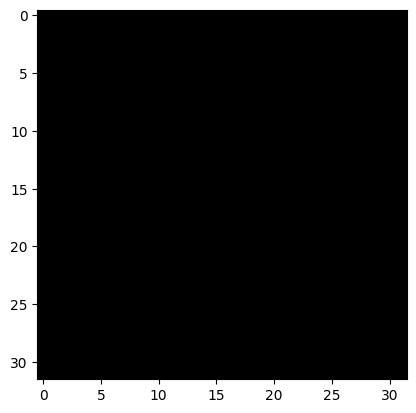

In [ ]:
plt.imshow(X_train[0])

In [ ]:

X_train.shape
X_test.shape

(10000, 32, 32, 3)

In [ ]:
y_train.shape

(50000,)

In [ ]:
y_train[:5] #first 5 values of output , 6 is frog 9, is frog-- it is 2d array, we dont want, we need category use reshape function

array([6, 9, 9, 4, 1], dtype=uint8)

In [ ]:
y_train=y_train.reshape(-1, ) # 2d convertes d to 1D array
y_train[:5]

array([6, 9, 9, 4, 1], dtype=uint8)

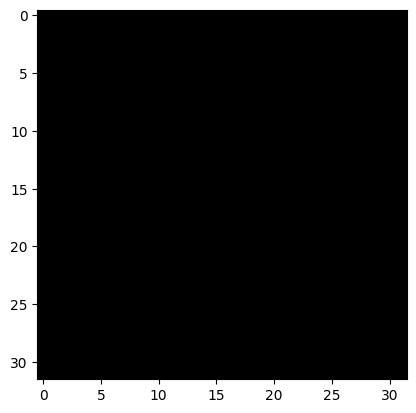

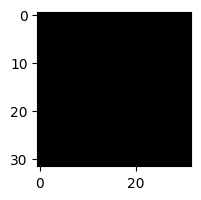

In [ ]:

X_train.shape # 50000 rows, 1 columns , Input data
y_train.shape # 50000 rows, 1 columns,Output data
X_train[0]  #first Input image
y_train[0]
X_train.shape
y_train.shape

plt.imshow(X_train[0]) # Larger so Resize the Image, Computer vision
plt.figure(figsize=(10,2))
plt.imshow(X_train[0])



In [ ]:
#Classes List vaaribale of my output - 0 t9 , Aeroplane to truck [[[[[y-Train - Labeled data- classes-category- output]]]
classes = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

In [ ]:
# Function Plot Sample
def plot_sample(X,y,Index):
    plt.figure(figsize = (20,5))
    plt.imshow(X[Index])
    plt.xlabel(classes[y[Index]])


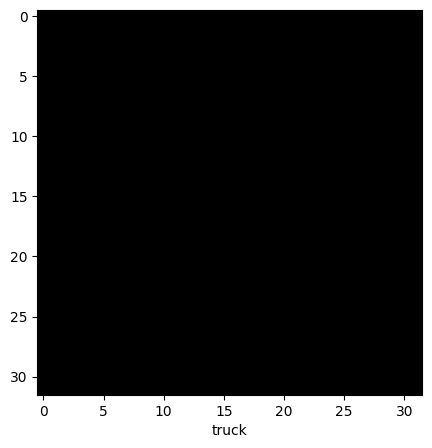

In [ ]:
plot_sample(X_train, y_train, 1)

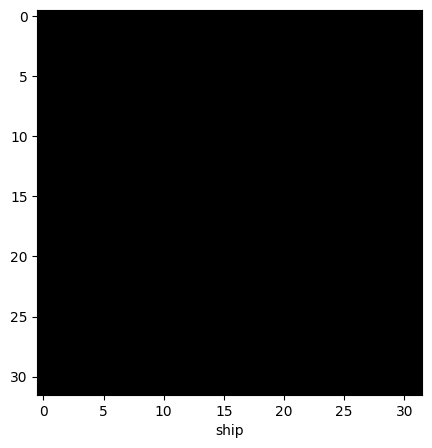

In [ ]:
plot_sample(X_train, y_train, 8)

In [ ]:
#Normalize the data Pixels 0 to 255 for each channel RGB
X_train[0] # here you could see values range from 0 to 255 ---> Normalize tg=he value from 0 to 1
X_train[0]/255 #--> See the output - 0 to 1  , divide every element by 255
X_test[0]/255

## so entire data has to be normalized --
X_train = X_train / 255
X_test= X_test / 255


In [ ]:
# Define the Sequential model architecture
ANN = models.Sequential(
    [
    layers.Input(shape=(32, 32, 3)), - Input layes
    layers.Flatten(),
    layers.Dense(3000, activation='relu'), # 2 deep NNs, First Deep Learning  has 3000 Nuerons
    layers.Dense(1000, activation='relu'), # second Deep Learning  has 1000 Nuerons
    layers.Dense(10, activation='sigmoid') # Output layer for multi classification , so used sig
])

In [ ]:
ANN.compile(
    optimizer="SGD",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
ANN.fit(X_train,y_train , epochs=5) #Total number of times to iterate over the entire dataset

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 160s 103ms/step - accuracy: 0.0967 - loss: 2.3027
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 202s 103ms/step - accuracy: 0.0968 - loss: 2.3027
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 135s 86ms/step - accuracy: 0.0987 - loss: 2.3027
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 147s 94ms/step - accuracy: 0.0978 - loss: 2.3027
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 191s 87ms/step - accuracy: 0.0994 - loss: 2.3027


In [ ]:
# use teh ANN model to pass test data and create a classification report
ANN.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.1000 - loss: 2.3026


[2.302600145339966, 0.10000000149011612]

In [ ]:
from sklearn.metrics import confusion_matrix,classification_report
import numpy as np
y_pred=ANN.predict (X_test)
y_pred_classes = [np.argmax(element) for element in y_pred]
print("Classification Report \n ", classification_report(y_test , y_pred_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 42ms/step
Classification Report 
                precision    recall  f1-score   support

           0       0.00      0.00      0.00      1000
           1       0.00      0.00      0.00      1000
           2       0.00      0.00      0.00      1000
           3       0.00      0.00      0.00      1000
           4       0.00      0.00      0.00      1000
           5       0.00      0.00      0.00      1000
           6       0.00      0.00      0.00      1000
           7       0.00      0.00      0.00      1000
           8       0.00      0.00      0.00      1000
           9       0.10      1.00      0.18      1000

    accuracy                           0.10     10000
   macro avg       0.01      0.10      0.02     10000
weighted avg       0.01      0.10      0.02     10000



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Develop a CNN model
cnn = models.Sequential(
    [
        #cnn
        layers.Input(shape=(32, 32, 3)),
        #layers.Conv2D(filters=32, kernal_size=(3,3), activation='relu'),

        layers.Conv2D(filters=32, kernel_size=(3,3),    activation='relu'),
        layers.MaxPooling2D(pool_size=(2,2)),

        layers.Conv2D(filters = 32, kernel_size = (3,3), activation='relu', input_shape= (32,32,3)),
        layers.MaxPooling2D(pool_size=(2,2)),

        # Dense
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax') # Output layer for multi classification , so used softmax

])
print('cnn created')

cnn created


In [ ]:
cnn.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
ANN.fit(X_train,y_train , epochs=5) #Total number of times to iterate over the entire dataset

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 138s 89ms/step - accuracy: 0.0986 - loss: 2.3027
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 151s 94ms/step - accuracy: 0.0978 - loss: 2.3027
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 136s 87ms/step - accuracy: 0.0985 - loss: 2.3027
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 182s 116ms/step - accuracy: 0.0988 - loss: 2.3027
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 156s 99ms/step - accuracy: 0.0976 - loss: 2.3027


In [ ]:
cnn.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.1020 - loss: 2.3026


[2.30259108543396, 0.10199999809265137]

In [ ]:
y_pred=cnn.predict (X_test)
y_pred[:5]
y_pred_classes = [np.argmax(element) for element in y_pred]
print("CNN- Classification Report \n ", classification_report(y_test , y_pred_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step
CNN- Classification Report 
                precision    recall  f1-score   support

           0       0.00      0.00      0.00      1000
           1       0.00      0.00      0.00      1000
           2       0.10      0.95      0.18      1000
           3       0.00      0.00      0.00      1000
           4       0.13      0.01      0.01      1000
           5       0.12      0.05      0.07      1000
           6       0.00      0.00      0.00      1000
           7       0.06      0.02      0.03      1000
           8       0.00      0.00      0.00      1000
           9       0.00      0.00      0.00      1000

    accuracy                           0.10     10000
   macro avg       0.04      0.10      0.03     10000
weighted avg       0.04      0.10      0.03     10000



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
y_test[:5]

array([[3],
       [8],
       [8],
       [0],
       [6]], dtype=uint8)

In [ ]:
y_test= y_test.reshape(-1, )
y_test[:5]


array([3, 8, 8, 0, 6], dtype=uint8)

In [ ]:
#y_pred[:5]
y_pred_classes = [np.argmax(element) for element in y_pred]
y_pred_classes[:5]

[np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2)]

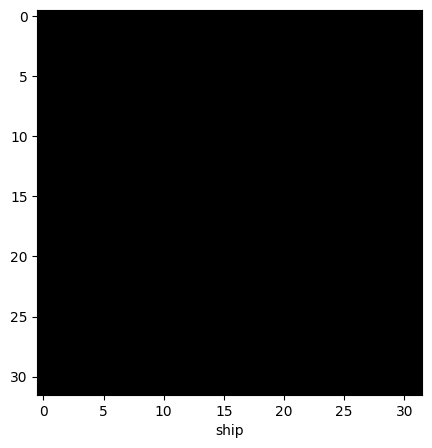

In [ ]:
plot_sample(X_test, y_test, 1)

In [ ]:
classes[y_pred_classes[5]]

'horse'

In [1]:
import gradio as gr

'''ADVICE = {
    "airplane"= "Airplane",
    "automobile" ="Automibile",
    "bird" ="Bird",
    "cat"= "cat",
    "deer" ="deer",
    "dog" ="dog",
    "frog" = "frog",
    "horse"= "horse",
    "ship"= "ship",
    "truck"= "truck",
}'''


import gradio as gr

# Define your model prediction function
def predict_image(image):
    # 'image' is passed as a PIL Image, NumPy array, or file path
    # depending on your gr.Image(type=...) setting.
    # Put your model inference code here.
    result = "Prediction Result"
    return result

# Create the Gradio interface
demo = gr.Interface(
    fn=predict_image,
    inputs=gr.Image(type="pil", label="Upload Image"),
    outputs=gr.Label(label="Prediction"),
    title="Computer Vision- Crop Image Classification Upload "
).launch(share=True)




Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://a976a5b830c2ad5053.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [2]:
import pickle
filename = 'ANN-Classification Model.pkl'
# Open a file in 'write binary' (wb) mode and dump the model
with open(filename, 'wb') as file:
    pickle.dump(ANN, file)
print(f"Model successfully saved as {filename}")
from google.colab import files
files.download('ANN-Classification Model.pkl')





NameError: name 'ANN' is not defined

In [ ]:
filename = 'CNN-Classification Model.pkl'
# Open a file in 'write binary' (wb) mode and dump the model
with open(filename, 'wb') as file:
    pickle.dump(cnn, file)
print(f"Model successfully saved as {filename}")

from google.colab import files
files.download('CNN-Classification Model.pkl')

Model successfully saved as CNN-Classification Model.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
Uploaded=files.upload()

Saving ANN-Classification Model.pkl to ANN-Classification Model (1).pkl
